In [1]:
# =============================================================================
# Solar Cell EL Image Binary Classification - Research Benchmark
# =============================================================================
# Module 0: Imports & Environment Setup
# Module 1: Configuration
# Module 2: Data Pipeline
# Module 3: CBAM Attention Module
# Module 4: Model Factory (ResNet, EfficientNet, ViT, Swin, ConvNeXt, DeiT)
# Module 5: Training & Evaluation Engine
# Module 6: Optuna Hyperparameter Search
# Module 7: Final Evaluation & Comparison
# Module 8: Research-Grade Visualization & Reporting
# =============================================================================

# %%
# ===========================================================================
# MODULE 0: Imports & Environment Setup
# ===========================================================================

!pip install optuna optuna[visualization] scikit-learn seaborn kaleido plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 96.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 614.2/614.2 kB 25.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [optuna];5;237m━━ 16/17 [optuna]learn]


In [2]:
import os
import json
import time
import copy
import warnings
import random
import logging
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.models import (
    resnet50, resnet101, ResNet50_Weights, ResNet101_Weights,
    efficientnet_b0, efficientnet_b3, efficientnet_b4,
    EfficientNet_B0_Weights, EfficientNet_B3_Weights, EfficientNet_B4_Weights,
    convnext_tiny, convnext_small, ConvNeXt_Tiny_Weights, ConvNeXt_Small_Weights,
    swin_t, swin_s, Swin_T_Weights, Swin_S_Weights,
    vit_b_16, vit_b_32, ViT_B_16_Weights, ViT_B_32_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    densenet121, DenseNet121_Weights,
)

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef
)

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")
print(f"✅ PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# %%
# ===========================================================================
# MODULE 1: Configuration
# ===========================================================================

class Config:
    """Central configuration. Edit paths and search settings here."""

    # ---- Paths ---------------------------------------------------------------
    # Root that directly contains train/, val/, test/ subdirectories
    DATA_ROOT = Path(r"/home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split")
    # Results are saved here (created automatically)
    RESULTS_DIR = DATA_ROOT / "benchmark_results"

    # ---- Classes -------------------------------------------------------------
    CLASS_NAMES = ["Bgrade", "ok"]   # order must match sub-folder names
    NUM_CLASSES = 2

    # ---- Image ---------------------------------------------------------------
    IMG_SIZE = 224          # all models expect 224

    # ---- Optuna Search -------------------------------------------------------
    N_TRIALS = 30           # Optuna trials per model family
    N_EPOCHS_TRIAL = 15     # epochs per Optuna trial  (keep low to save time)
    N_EPOCHS_FINAL = 40     # epochs for final retraining of each best config
    PRUNING = True          # prune bad trials early
    DIRECTION = "maximize"  # maximise validation F1 macro

    # ---- Dataloader ----------------------------------------------------------
    NUM_WORKERS = 0         # set to 0 on Windows to avoid multiprocessing issues
    PIN_MEMORY  = True if torch.cuda.is_available() else False

    # ---- Model families to benchmark -----------------------------------------
    # Each entry: family_name -> list of variant keys for Optuna to choose from
    MODEL_FAMILIES = {
        "ResNet":        ["resnet50",          "resnet101"],
        "EfficientNet":  ["efficientnet_b0",   "efficientnet_b3", "efficientnet_b4"],
        "ConvNeXt":      ["convnext_tiny",     "convnext_small"],
        "MobileNet":     ["mobilenet_v3_large"],
        "DenseNet":      ["densenet121"],
        "Swin":          ["swin_t",            "swin_s"],
        "ViT":           ["vit_b_16",          "vit_b_32"],
    }

    # Optuna search space (shared)
    LR_RANGE          = (1e-5, 1e-2)
    WD_RANGE          = (1e-6, 1e-2)
    DROPOUT_RANGE     = (0.0,  0.5)
    BATCH_SIZES       = [16, 32]
    OPTIMIZERS        = ["Adam", "AdamW", "SGD"]
    SCHEDULERS        = ["cosine", "step", "onecycle"]
    USE_CBAM_CHOICES  = [True, False]
    FREEZE_CHOICES    = ["none", "partial", "full"]   # backbone freezing strategy


CFG = Config()
CFG.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(CFG.RESULTS_DIR / "plots").mkdir(exist_ok=True)
(CFG.RESULTS_DIR / "checkpoints").mkdir(exist_ok=True)
(CFG.RESULTS_DIR / "metrics").mkdir(exist_ok=True)

print(f"✅ Results will be saved to: {CFG.RESULTS_DIR}")

✅ Device: cuda
✅ PyTorch: 2.12.0+cu130
✅ GPU: NVIDIA RTX PRO 4500 Blackwell
✅ VRAM: 33.7 GB
✅ Results will be saved to: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results


/home/user/anaconda3/envs/raj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# %%
# ===========================================================================
# MODULE 2: Data Pipeline
# ===========================================================================

def get_transforms(split: str, img_size: int = 224):
    """
    Returns torchvision transforms for each split.
    Training uses aggressive augmentation suitable for small EL image datasets.
    Val/Test uses deterministic centre-crop only.
    """
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(imagenet_mean, imagenet_std),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(imagenet_mean, imagenet_std),
        ])


def build_dataloaders(batch_size: int, img_size: int = 224):
    """Creates train/val/test DataLoaders from the split folder structure."""
    loaders = {}
    datasets_dict = {}

    for split in ["train", "val", "test"]:
        split_dir = CFG.DATA_ROOT / split
        if not split_dir.exists():
            raise FileNotFoundError(
                f"Split directory not found: {split_dir}\n"
                f"Expected: {CFG.DATA_ROOT}/train|val|test/Bgrade|ok/"
            )
        tfm = get_transforms(split, img_size)
        ds  = datasets.ImageFolder(str(split_dir), transform=tfm)
        datasets_dict[split] = ds
        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=CFG.NUM_WORKERS,
            pin_memory=CFG.PIN_MEMORY,
            drop_last=(split == "train"),
        )

    class_to_idx = datasets_dict["train"].class_to_idx
    logger.info(f"Class mapping: {class_to_idx}")
    print(f"📂 Dataset splits:")
    for split, ds in datasets_dict.items():
        counts = {}
        for cls in ds.classes:
            counts[cls] = 0
        for _, label in ds.samples:
            counts[ds.classes[label]] += 1
        print(f"   {split:5s}: {len(ds):5d} images | {counts}")

    return loaders, class_to_idx


In [4]:
# Quick sanity check - comment this out if your dataset directory isn't ready yet
_loaders, _c2i = build_dataloaders(batch_size=4)

2026-07-02 22:39:34,347 - INFO - Class mapping: {'Bgrade': 0, 'ok': 1}


📂 Dataset splits:
   train:  6575 images | {'Bgrade': 2147, 'ok': 4428}
   val  :  1408 images | {'Bgrade': 454, 'ok': 954}
   test :  1409 images | {'Bgrade': 460, 'ok': 949}


In [5]:
# %%
# ===========================================================================
# MODULE 3: CBAM Attention Module
# ===========================================================================

class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation style channel attention."""
    def __init__(self, in_channels: int, reduction_ratio: int = 16):
        super().__init__()
        reduced = max(1, in_channels // reduction_ratio)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg = self.avg_pool(x).view(b, c)
        mx  = self.max_pool(x).view(b, c)
        out = self.sigmoid(self.fc(avg) + self.fc(mx))
        return x * out.view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    """Spatial attention using channel-wise statistics."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * scale


class CBAM(nn.Module):
    """Convolutional Block Attention Module (Woo et al., ECCV 2018)."""
    def __init__(self, in_channels: int, reduction_ratio: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.channel = ChannelAttention(in_channels, reduction_ratio)
        self.spatial = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x


class CBAMClassifier(nn.Module):
    """
    Wraps a CNN backbone and inserts a CBAM module before the
    global pooling + classifier head.
    Compatible with: ResNet, EfficientNet, ConvNeXt, MobileNet, DenseNet.
    """
    def __init__(self, backbone: nn.Module, feature_dim: int,
                 num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.backbone   = backbone
        self.cbam       = CBAM(feature_dim)
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.cbam(x)
        x = self.pool(x)
        return self.classifier(x)



In [6]:
# %%
# ===========================================================================
# MODULE 4: Model Factory
# ===========================================================================

def _apply_freeze(model: nn.Module, strategy: str) -> nn.Module:
    """
    Freeze backbone layers according to strategy.
    none    -> all layers trainable (fine-tune everything)
    partial -> freeze first 60% of layers, train rest + head
    full    -> freeze all backbone, train head only
    """
    if strategy == "none":
        for p in model.parameters():
            p.requires_grad = True
        return model

    all_params = list(model.named_parameters())

    if strategy == "full":
        for name, p in all_params:
            is_head = any(k in name for k in ["classifier", "head", "fc", "heads"])
            p.requires_grad = is_head

    elif strategy == "partial":
        cutoff = int(len(all_params) * 0.6)
        for i, (name, p) in enumerate(all_params):
            p.requires_grad = (i >= cutoff)

    return model


def build_model(model_key: str, use_cbam: bool, freeze: str,
                dropout: float, num_classes: int) -> nn.Module:
    """
    Factory function returning a configured model ready for training.

    Parameters
    ----------
    model_key  : Architecture identifier string
    use_cbam   : Insert CBAM before head (CNN models only; ignored for transformers)
    freeze     : 'none' | 'partial' | 'full'
    dropout    : Dropout probability before the final linear layer
    num_classes: Output classes (2 for binary)
    """

    # ---- CNN-based models (support CBAM) ------------------------------------
    if model_key == "resnet50":
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        feat_dim = backbone.fc.in_features
        if use_cbam:
            backbone.fc = nn.Identity()
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "resnet101":
        backbone = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
        feat_dim = backbone.fc.in_features
        if use_cbam:
            backbone.fc = nn.Identity()
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "efficientnet_b0":
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "efficientnet_b3":
        backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "efficientnet_b4":
        backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "convnext_tiny":
        backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier[2].in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(
                nn.Flatten(), nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "convnext_small":
        backbone = convnext_small(weights=ConvNeXt_Small_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier[2].in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(
                nn.Flatten(), nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "mobilenet_v3_large":
        backbone = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        feat_dim = backbone.classifier[0].in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    elif model_key == "densenet121":
        backbone = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
        if use_cbam:
            model = CBAMClassifier(backbone, feat_dim, num_classes, dropout)
        else:
            backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
            model = backbone

    # ---- Transformer-based models (CBAM skipped - attention is built in) ----
    elif model_key == "swin_t":
        backbone = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)
        feat_dim = backbone.head.in_features
        backbone.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
        model = backbone

    elif model_key == "swin_s":
        backbone = swin_s(weights=Swin_S_Weights.IMAGENET1K_V1)
        feat_dim = backbone.head.in_features
        backbone.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
        model = backbone

    elif model_key == "vit_b_16":
        backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        feat_dim = backbone.heads.head.in_features
        backbone.heads.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
        model = backbone

    elif model_key == "vit_b_32":
        backbone = vit_b_32(weights=ViT_B_32_Weights.IMAGENET1K_V1)
        feat_dim = backbone.heads.head.in_features
        backbone.heads.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, num_classes))
        model = backbone

    else:
        raise ValueError(f"Unknown model key: '{model_key}'")

    model = _apply_freeze(model, freeze)
    return model.to(DEVICE)


def count_params(model: nn.Module):
    """Returns (total_params, trainable_params) tuple."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [7]:
# %%
# ===========================================================================
# MODULE 5: Training & Evaluation Engine
# ===========================================================================

class EarlyStopping:
    """Stops training when validation metric stops improving."""
    def __init__(self, patience: int = 8, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score: float):
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter = 0


def build_optimizer(name: str, model: nn.Module, lr: float, wd: float):
    params = [p for p in model.parameters() if p.requires_grad]
    if name == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif name == "AdamW":
        return optim.AdamW(params, lr=lr, weight_decay=wd)
    elif name == "SGD":
        return optim.SGD(params, lr=lr, weight_decay=wd, momentum=0.9, nesterov=True)
    raise ValueError(f"Unknown optimizer: {name}")


def build_scheduler(name: str, optimizer, n_epochs: int, steps_per_epoch: int):
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    elif name == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(1, n_epochs // 3), gamma=0.5)
    elif name == "onecycle":
        return optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=optimizer.param_groups[0]["lr"] * 10,
            epochs=n_epochs,
            steps_per_epoch=steps_per_epoch,
        )
    raise ValueError(f"Unknown scheduler: {name}")


def train_one_epoch(model, loader, criterion, optimizer, scheduler, is_onecycle=False):
    """Single training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if is_onecycle:
            scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        preds       = out.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluation pass. Returns (avg_loss, acc, f1_macro, preds, labels, probs)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out   = model(imgs)
        loss  = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        probs = F.softmax(out, dim=1)
        preds = probs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    avg_loss = total_loss / total
    acc      = correct / total
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def run_training(model, loaders, n_epochs, optimizer, scheduler, scheduler_name,
                 trial=None, use_pruning=False):
    """
    Full training loop with early stopping and optional Optuna pruning.

    Returns
    -------
    history       : dict of per-epoch metrics
    best_weights  : model state_dict at the best validation F1
    best_val_f1   : float, best validation F1 achieved
    """
    criterion    = nn.CrossEntropyLoss(label_smoothing=0.05)
    es           = EarlyStopping(patience=8)
    best_val_f1  = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    history      = defaultdict(list)
    is_onecycle  = (scheduler_name == "onecycle")

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, loaders["train"], criterion, optimizer, scheduler, is_onecycle)
        vl_loss, vl_acc, vl_f1, _, _, _ = evaluate(model, loaders["val"], criterion)

        if not is_onecycle:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            best_weights = copy.deepcopy(model.state_dict())

        elapsed = time.time() - t0
        print(f"  Epoch {epoch:03d}/{n_epochs} | "
              f"TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | "
              f"VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} VlF1={vl_f1:.3f} | "
              f"{elapsed:.1f}s")

        # Optuna pruning support
        if trial is not None and use_pruning:
            trial.report(vl_f1, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        es(vl_f1)
        if es.stop:
            print(f"  ⏹ Early stopping triggered at epoch {epoch}")
            break

    model.load_state_dict(best_weights)
    return history, best_weights, best_val_f1


In [8]:
# %%
# ===========================================================================
# MODULE 6: Optuna Hyperparameter Search
# ===========================================================================

# Global store: family -> final result dict (populated in Module 7)
BENCHMARK_RESULTS = {}


def make_objective(family_name: str, variant_list: list):
    """
    Returns an Optuna objective function scoped to the given model family.
    Each trial samples: model variant, optimizer, scheduler, lr, wd,
    dropout, batch_size, cbam, freeze strategy.
    """
    def objective(trial: optuna.Trial) -> float:
        # --- Sample hyperparameters -------------------------------------------
        model_key  = trial.suggest_categorical("model_key",  variant_list)
        optimizer_ = trial.suggest_categorical("optimizer",  CFG.OPTIMIZERS)
        scheduler_ = trial.suggest_categorical("scheduler",  CFG.SCHEDULERS)
        lr         = trial.suggest_float("lr",               *CFG.LR_RANGE, log=True)
        wd         = trial.suggest_float("weight_decay",     *CFG.WD_RANGE, log=True)
        dropout    = trial.suggest_float("dropout",          *CFG.DROPOUT_RANGE)
        batch_size = trial.suggest_categorical("batch_size", CFG.BATCH_SIZES)
        freeze     = trial.suggest_categorical("freeze",     CFG.FREEZE_CHOICES)

        # CBAM applies only to CNN architectures (transformers have built-in attention)
        is_transformer = model_key in {"swin_t", "swin_s", "vit_b_16", "vit_b_32"}
        use_cbam = False
        if not is_transformer:
            use_cbam = trial.suggest_categorical("use_cbam", CFG.USE_CBAM_CHOICES)

        try:
            model   = build_model(model_key, use_cbam, freeze, dropout, CFG.NUM_CLASSES)
            loaders, _ = build_dataloaders(batch_size)
            opt     = build_optimizer(optimizer_, model, lr, wd)
            sched   = build_scheduler(scheduler_, opt, CFG.N_EPOCHS_TRIAL, len(loaders["train"]))

            _, _, best_f1 = run_training(
                model, loaders, CFG.N_EPOCHS_TRIAL,
                opt, sched, scheduler_,
                trial=trial, use_pruning=CFG.PRUNING,
            )
        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            logger.warning(f"Trial failed with error: {e}")
            return 0.0
        finally:
            torch.cuda.empty_cache()

        return best_f1

    return objective


def run_optuna_for_family(family_name: str, variant_list: list):
    """Runs an Optuna study for one model family. Returns (study, best_params, best_score)."""
    print(f"\n{'='*70}")
    print(f"🔍  Optuna Search: {family_name}  |  variants = {variant_list}")
    print(f"{'='*70}")

    pruner = (
        optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
        if CFG.PRUNING else optuna.pruners.NopPruner()
    )

    study = optuna.create_study(
        direction=CFG.DIRECTION,
        pruner=pruner,
        study_name=f"{family_name}_{datetime.now().strftime('%H%M%S')}",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )

    study.optimize(
        make_objective(family_name, variant_list),
        n_trials=CFG.N_TRIALS,
        gc_after_trial=True,
    )

    best = study.best_trial
    print(f"\n✅ Best trial for {family_name}:  F1 = {best.value:.4f}")
    print(f"   Params: {best.params}")

    # Save Optuna visualizations (requires plotly installed)
    try:
        fig = plot_optimization_history(study)
        fig.write_image(str(CFG.RESULTS_DIR / "plots" / f"optuna_history_{family_name}.png"))
        fig = plot_param_importances(study)
        fig.write_image(str(CFG.RESULTS_DIR / "plots" / f"optuna_importance_{family_name}.png"))
    except Exception as e:
        logger.warning(f"Optuna plots failed (install kaleido for image export): {e}")

    # Save all trial data to CSV
    df = study.trials_dataframe()
    df.to_csv(CFG.RESULTS_DIR / "metrics" / f"optuna_trials_{family_name}.csv", index=False)

    return study, best.params, best.value


def run_all_optuna():
    """Runs Optuna search for all families defined in CFG.MODEL_FAMILIES."""
    all_best_params = {}
    all_best_scores = {}

    for family, variants in CFG.MODEL_FAMILIES.items():
        _, best_params, best_score = run_optuna_for_family(family, variants)
        all_best_params[family] = best_params
        all_best_scores[family] = best_score

    print("\n\n📋 Optuna Summary (Val F1 Macro):")
    for fam, score in sorted(all_best_scores.items(), key=lambda x: -x[1]):
        print(f"   {fam:15s}  {score:.4f}  |  best params: {all_best_params[fam]}")

    return all_best_params, all_best_scores


[I 2026-07-02 22:41:16,510] A new study created in memory with name: ResNet_224116


  SOLAR CELL EL IMAGE CLASSIFICATION — OPTUNA BENCHMARK
  Data root      : /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split
  Results dir    : /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results
  Device         : cuda
  Model families : ['ResNet', 'EfficientNet', 'ConvNeXt', 'MobileNet', 'DenseNet', 'Swin', 'ViT']
  Trials/family  : 30
  Epochs (trial) : 15
  Epochs (final) : 40

🔍  Optuna Search: ResNet  |  variants = ['resnet50', 'resnet101']
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/user/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|████████████████████████████████████████| 171M/171M [00:01<00:00, 96.3MB/s]
2026-07-02 22:41:19,596 - INFO - Class mapping: {'Bgrade': 0, 'ok': 1}


📂 Dataset splits:
   train:  6575 images | {'Bgrade': 2147, 'ok': 4428}
   val  :  1408 images | {'Bgrade': 454, 'ok': 954}
   test :  1409 images | {'Bgrade': 460, 'ok': 949}
  Epoch 001/15 | TrLoss=0.5054 TrAcc=0.796 | VlLoss=6.4885 VlAcc=0.691 VlF1=0.516 | 42.7s
  Epoch 002/15 | TrLoss=0.6783 TrAcc=0.716 | VlLoss=0.6010 VlAcc=0.678 VlF1=0.404 | 40.0s
  Epoch 003/15 | TrLoss=0.6962 TrAcc=0.663 | VlLoss=0.6399 VlAcc=0.678 VlF1=0.404 | 42.2s
  Epoch 004/15 | TrLoss=0.6376 TrAcc=0.670 | VlLoss=1.2489 VlAcc=0.678 VlF1=0.404 | 42.6s
  Epoch 005/15 | TrLoss=0.6038 TrAcc=0.681 | VlLoss=0.6497 VlAcc=0.678 VlF1=0.404 | 42.3s
  Epoch 006/15 | TrLoss=0.6104 TrAcc=0.691 | VlLoss=0.5557 VlAcc=0.746 VlF1=0.691 | 41.7s
  Epoch 007/15 | TrLoss=0.5841 TrAcc=0.706 | VlLoss=0.6679 VlAcc=0.619 VlF1=0.537 | 41.7s
  Epoch 008/15 | TrLoss=0.5682 TrAcc=0.726 | VlLoss=0.6451 VlAcc=0.739 VlF1=0.613 | 42.2s
  Epoch 009/15 | TrLoss=0.5535 TrAcc=0.739 | VlLoss=0.5336 VlAcc=0.781 VlF1=0.707 | 42.5s
  Epoch 010/15

[I 2026-07-02 22:51:45,705] Trial 0 finished with value: 0.7125608795823734 and parameters: {'model_key': 'resnet101', 'optimizer': 'Adam', 'scheduler': 'onecycle', 'lr': 0.0006358358856676254, 'weight_decay': 0.0006796578090758161, 'dropout': 0.010292247147901223, 'batch_size': 16, 'freeze': 'none', 'use_cbam': False}. Best is trial 0 with value: 0.7125608795823734.


...


🏋️  Final Training: DenseNet
    Params: {'model_key': 'densenet121', 'optimizer': 'AdamW', 'scheduler': 'cosine', 'lr': 0.00014320037164520648, 'weight_decay': 0.00312719005643524, 'dropout': 0.36738901466096086, 'batch_size': 32, 'freeze': 'none', 'use_cbam': False}
📂 Dataset splits:
   train:  6575 images | {'Bgrade': 2147, 'ok': 4428}
   val  :  1408 images | {'Bgrade': 454, 'ok': 954}
   test :  1409 images | {'Bgrade': 460, 'ok': 949}
   Parameters: total=6,955,906  trainable=6,955,906
  Epoch 001/40 | TrLoss=0.4283 TrAcc=0.831 | VlLoss=0.5463 VlAcc=0.739 VlF1=0.732 | 34.2s
  Epoch 002/40 | TrLoss=0.3689 TrAcc=0.875 | VlLoss=1.7355 VlAcc=0.669 VlF1=0.665 | 34.3s
  Epoch 003/40 | TrLoss=0.3435 TrAcc=0.891 | VlLoss=0.4689 VlAcc=0.795 VlF1=0.786 | 34.3s
  Epoch 004/40 | TrLoss=0.3267 TrAcc=0.901 | VlLoss=0.2894 VlAcc=0.920 VlF1=0.908 | 34.2s
  Epoch 005/40 | TrLoss=0.3155 TrAcc=0.906 | VlLoss=0.3697 VlAcc=0.874 VlF1=0.863 | 34.6s
  Epoch 006/40 | TrLoss=0.3084 TrAcc=0.911 | VlLoss=

2026-07-03 19:00:44,598 - INFO - Class mapping: {'Bgrade': 0, 'ok': 1}


📂 Dataset splits:
   train:  6575 images | {'Bgrade': 2147, 'ok': 4428}
   val  :  1408 images | {'Bgrade': 454, 'ok': 954}
   test :  1409 images | {'Bgrade': 460, 'ok': 949}
   Parameters: total=48,838,796  trainable=48,838,796
  Epoch 001/40 | TrLoss=0.3518 TrAcc=0.888 | VlLoss=0.2871 VlAcc=0.923 VlF1=0.908 | 53.1s
  Epoch 002/40 | TrLoss=0.3110 TrAcc=0.914 | VlLoss=0.3042 VlAcc=0.923 VlF1=0.911 | 53.0s
  Epoch 003/40 | TrLoss=0.2952 TrAcc=0.920 | VlLoss=0.2690 VlAcc=0.935 VlF1=0.925 | 53.0s
  Epoch 004/40 | TrLoss=0.2871 TrAcc=0.924 | VlLoss=0.2722 VlAcc=0.929 VlF1=0.914 | 53.2s
  Epoch 005/40 | TrLoss=0.2872 TrAcc=0.922 | VlLoss=0.2413 VlAcc=0.944 VlF1=0.933 | 53.1s
  Epoch 006/40 | TrLoss=0.2765 TrAcc=0.929 | VlLoss=0.2392 VlAcc=0.952 VlF1=0.944 | 53.6s
  Epoch 007/40 | TrLoss=0.2733 TrAcc=0.932 | VlLoss=0.2479 VlAcc=0.942 VlF1=0.933 | 53.6s
  Epoch 008/40 | TrLoss=0.2716 TrAcc=0.933 | VlLoss=0.2618 VlAcc=0.944 VlF1=0.936 | 53.2s
  Epoch 009/40 | TrLoss=0.2726 TrAcc=0.933 | VlLos

2026-07-03 19:17:49,428 - INFO - Class mapping: {'Bgrade': 0, 'ok': 1}


📂 Dataset splits:
   train:  6575 images | {'Bgrade': 2147, 'ok': 4428}
   val  :  1408 images | {'Bgrade': 454, 'ok': 954}
   test :  1409 images | {'Bgrade': 460, 'ok': 949}
   Parameters: total=85,800,194  trainable=85,800,194
  Epoch 001/40 | TrLoss=0.3631 TrAcc=0.878 | VlLoss=0.3099 VlAcc=0.907 VlF1=0.884 | 62.0s
  Epoch 002/40 | TrLoss=0.3224 TrAcc=0.903 | VlLoss=0.3126 VlAcc=0.917 VlF1=0.903 | 62.1s
  Epoch 003/40 | TrLoss=0.3115 TrAcc=0.908 | VlLoss=0.2564 VlAcc=0.935 VlF1=0.922 | 62.2s
  Epoch 004/40 | TrLoss=0.2997 TrAcc=0.918 | VlLoss=0.2796 VlAcc=0.924 VlF1=0.909 | 62.3s
  Epoch 005/40 | TrLoss=0.2971 TrAcc=0.916 | VlLoss=0.2792 VlAcc=0.925 VlF1=0.909 | 62.4s
  Epoch 006/40 | TrLoss=0.2963 TrAcc=0.914 | VlLoss=0.2795 VlAcc=0.940 VlF1=0.929 | 62.7s
  Epoch 007/40 | TrLoss=0.2841 TrAcc=0.922 | VlLoss=0.3349 VlAcc=0.891 VlF1=0.876 | 63.1s
  Epoch 008/40 | TrLoss=0.2929 TrAcc=0.918 | VlLoss=0.2583 VlAcc=0.936 VlF1=0.924 | 62.3s
  Epoch 009/40 | TrLoss=0.2866 TrAcc=0.924 | VlLos

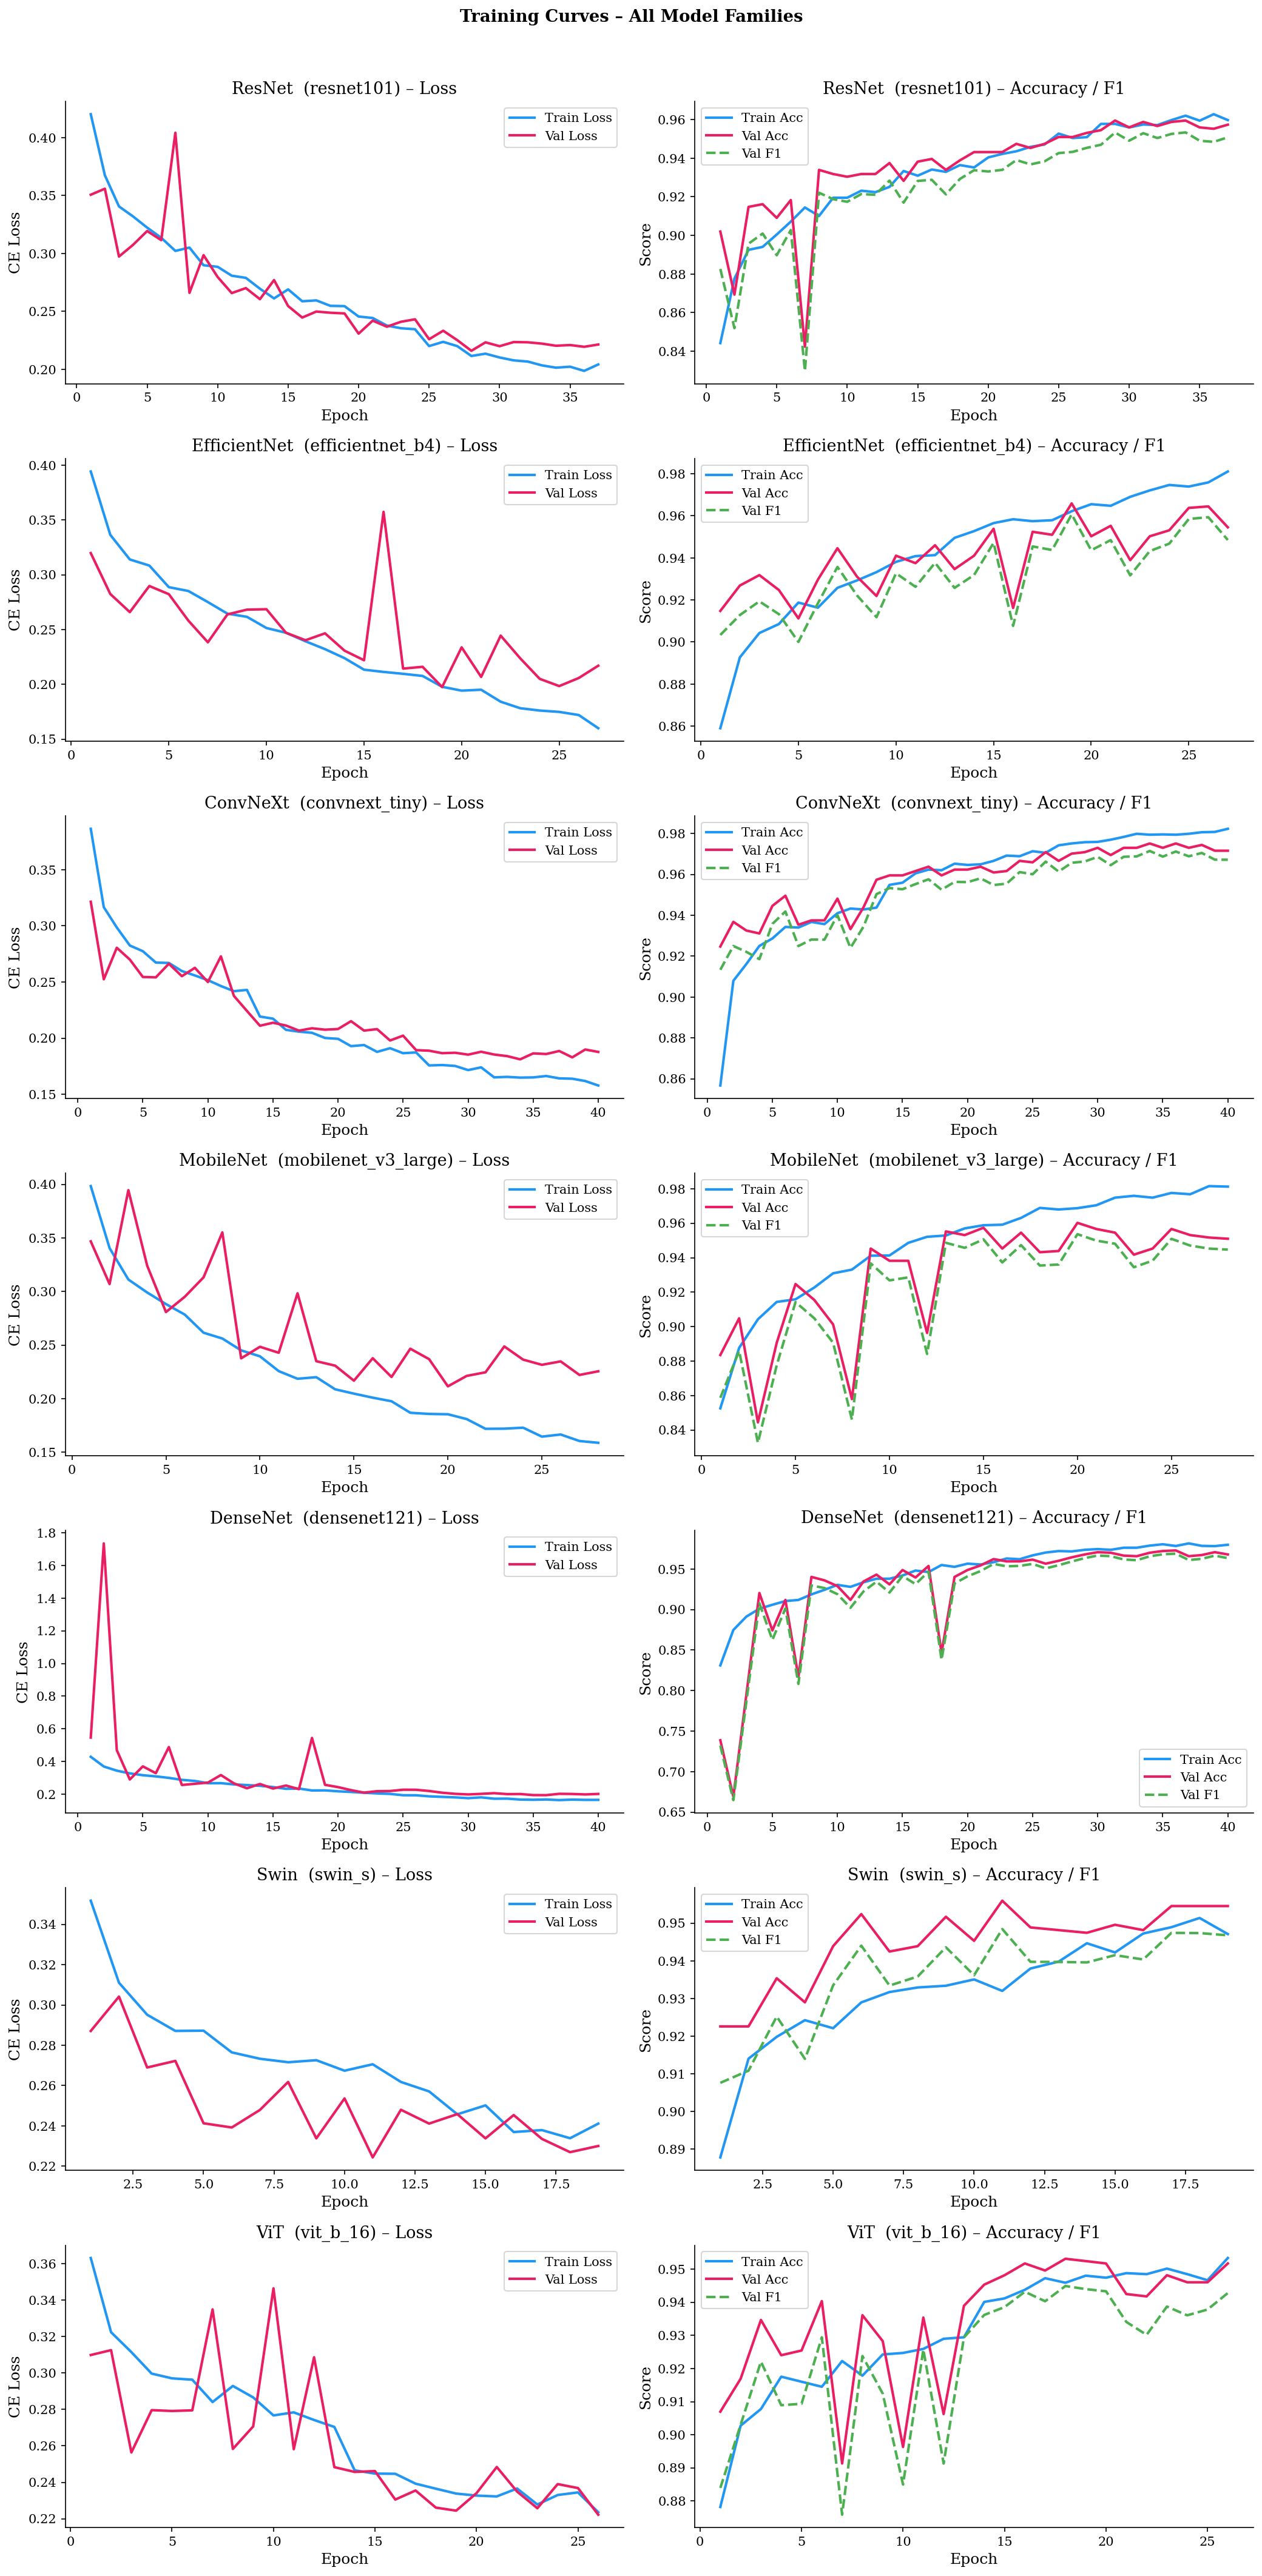

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/training_curves.png


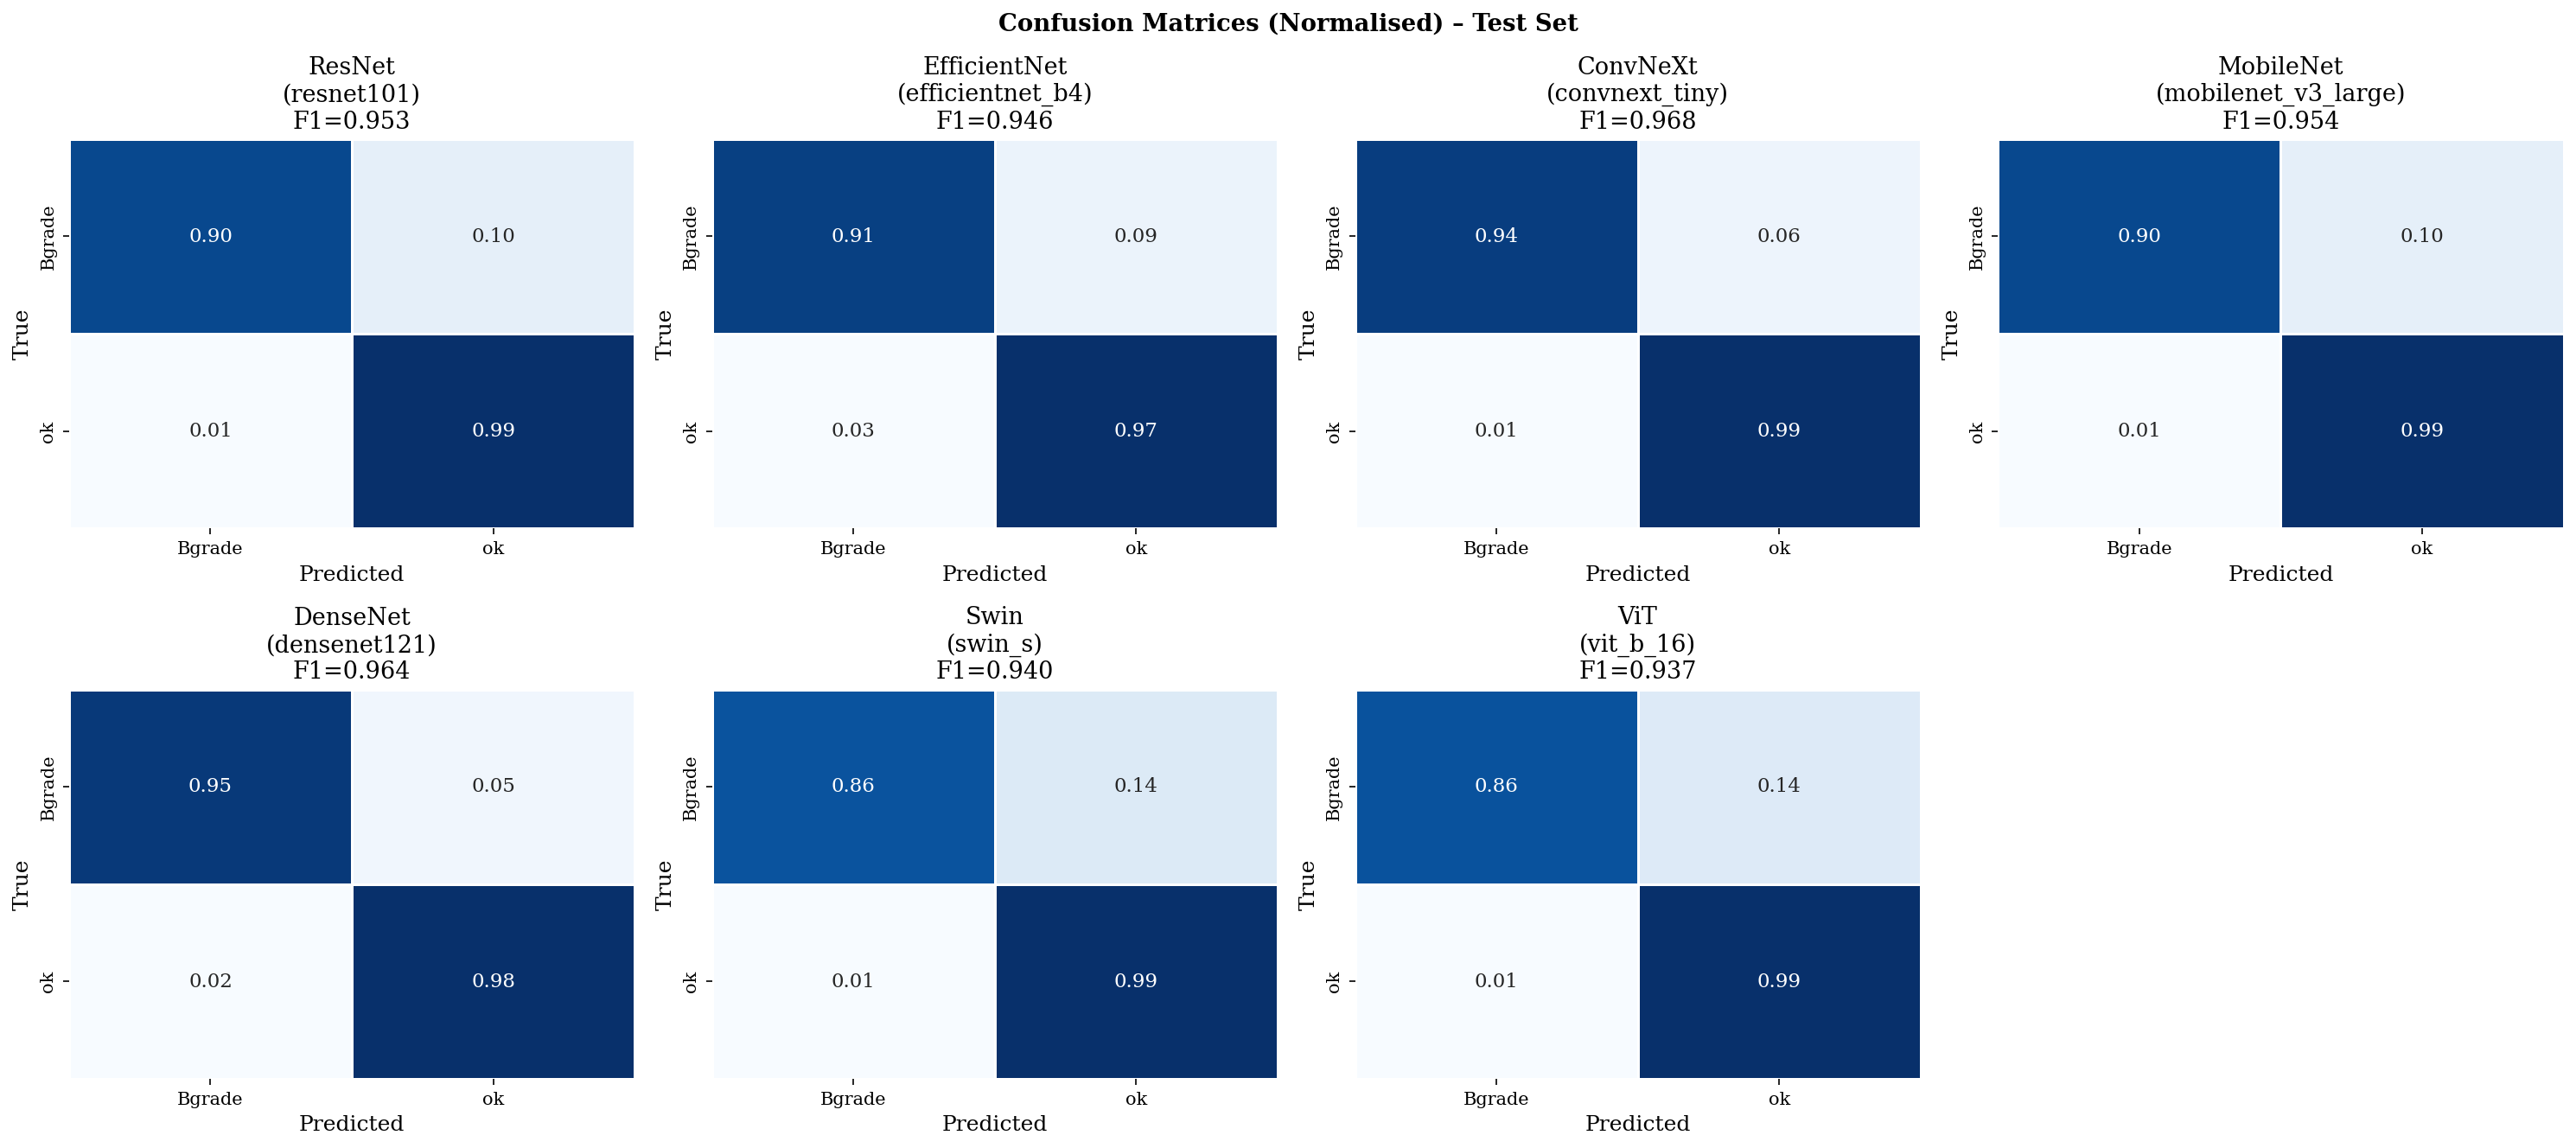

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/confusion_matrices.png


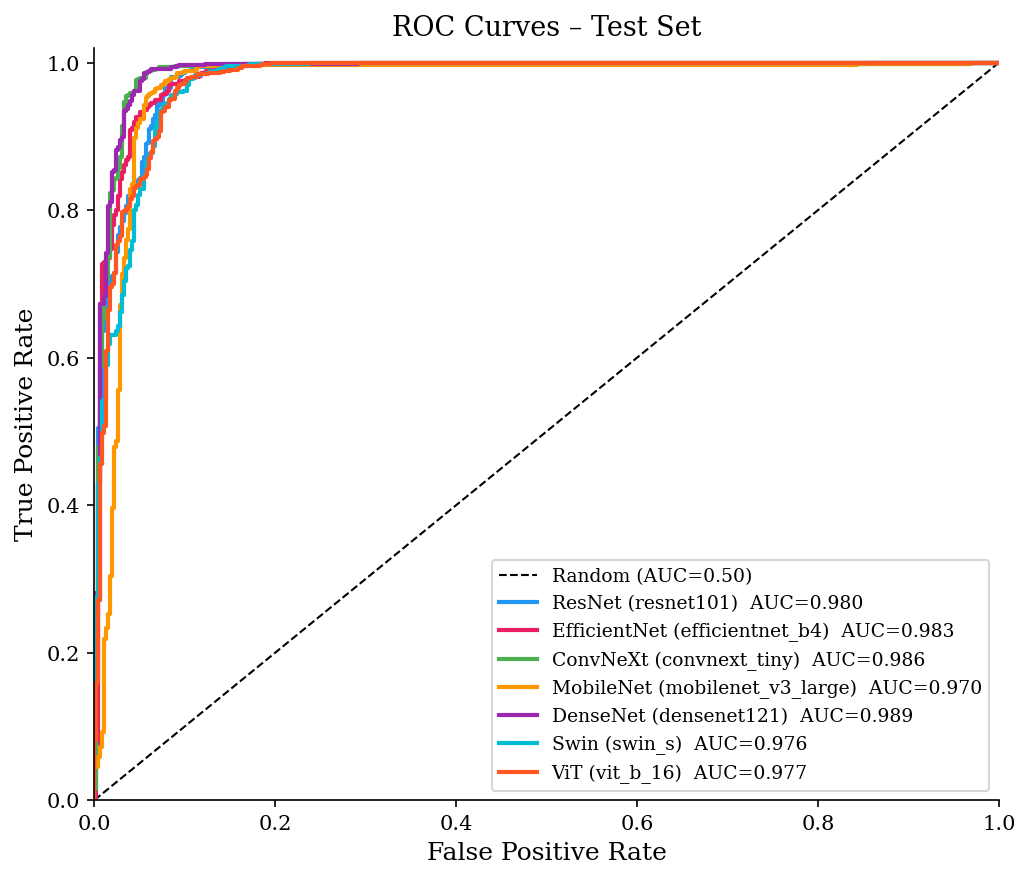

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/roc_curves.png


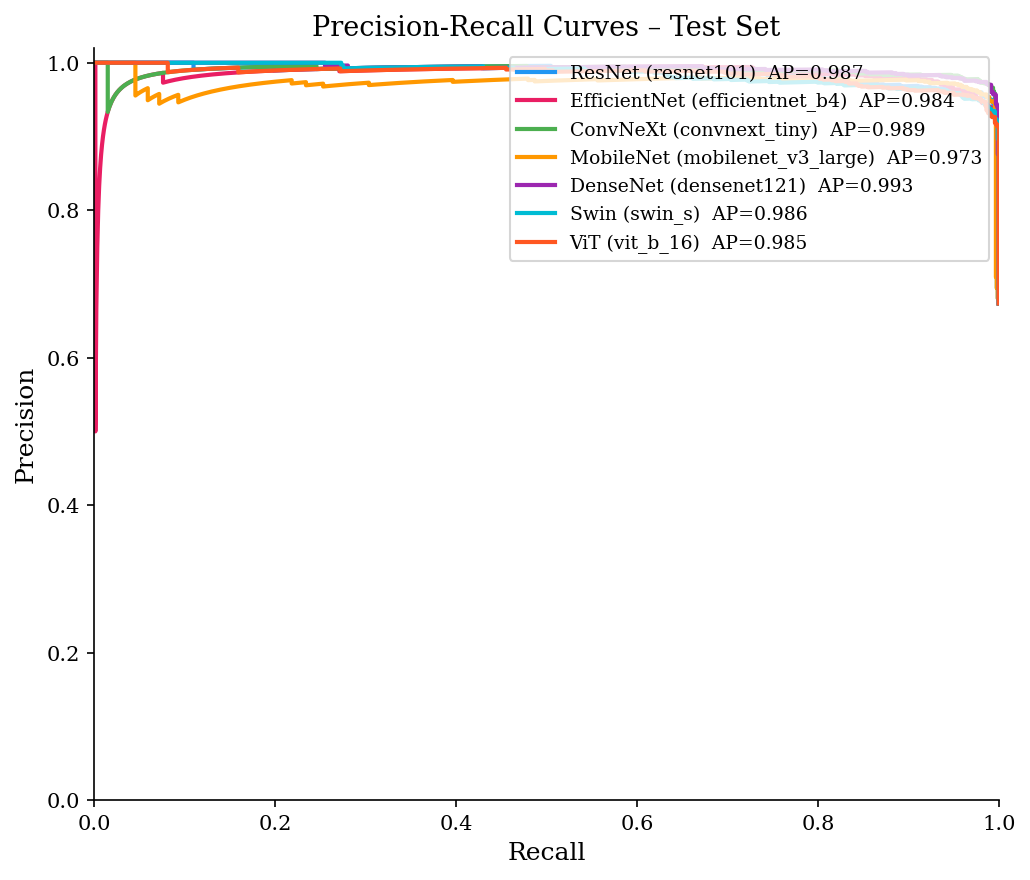

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/pr_curves.png


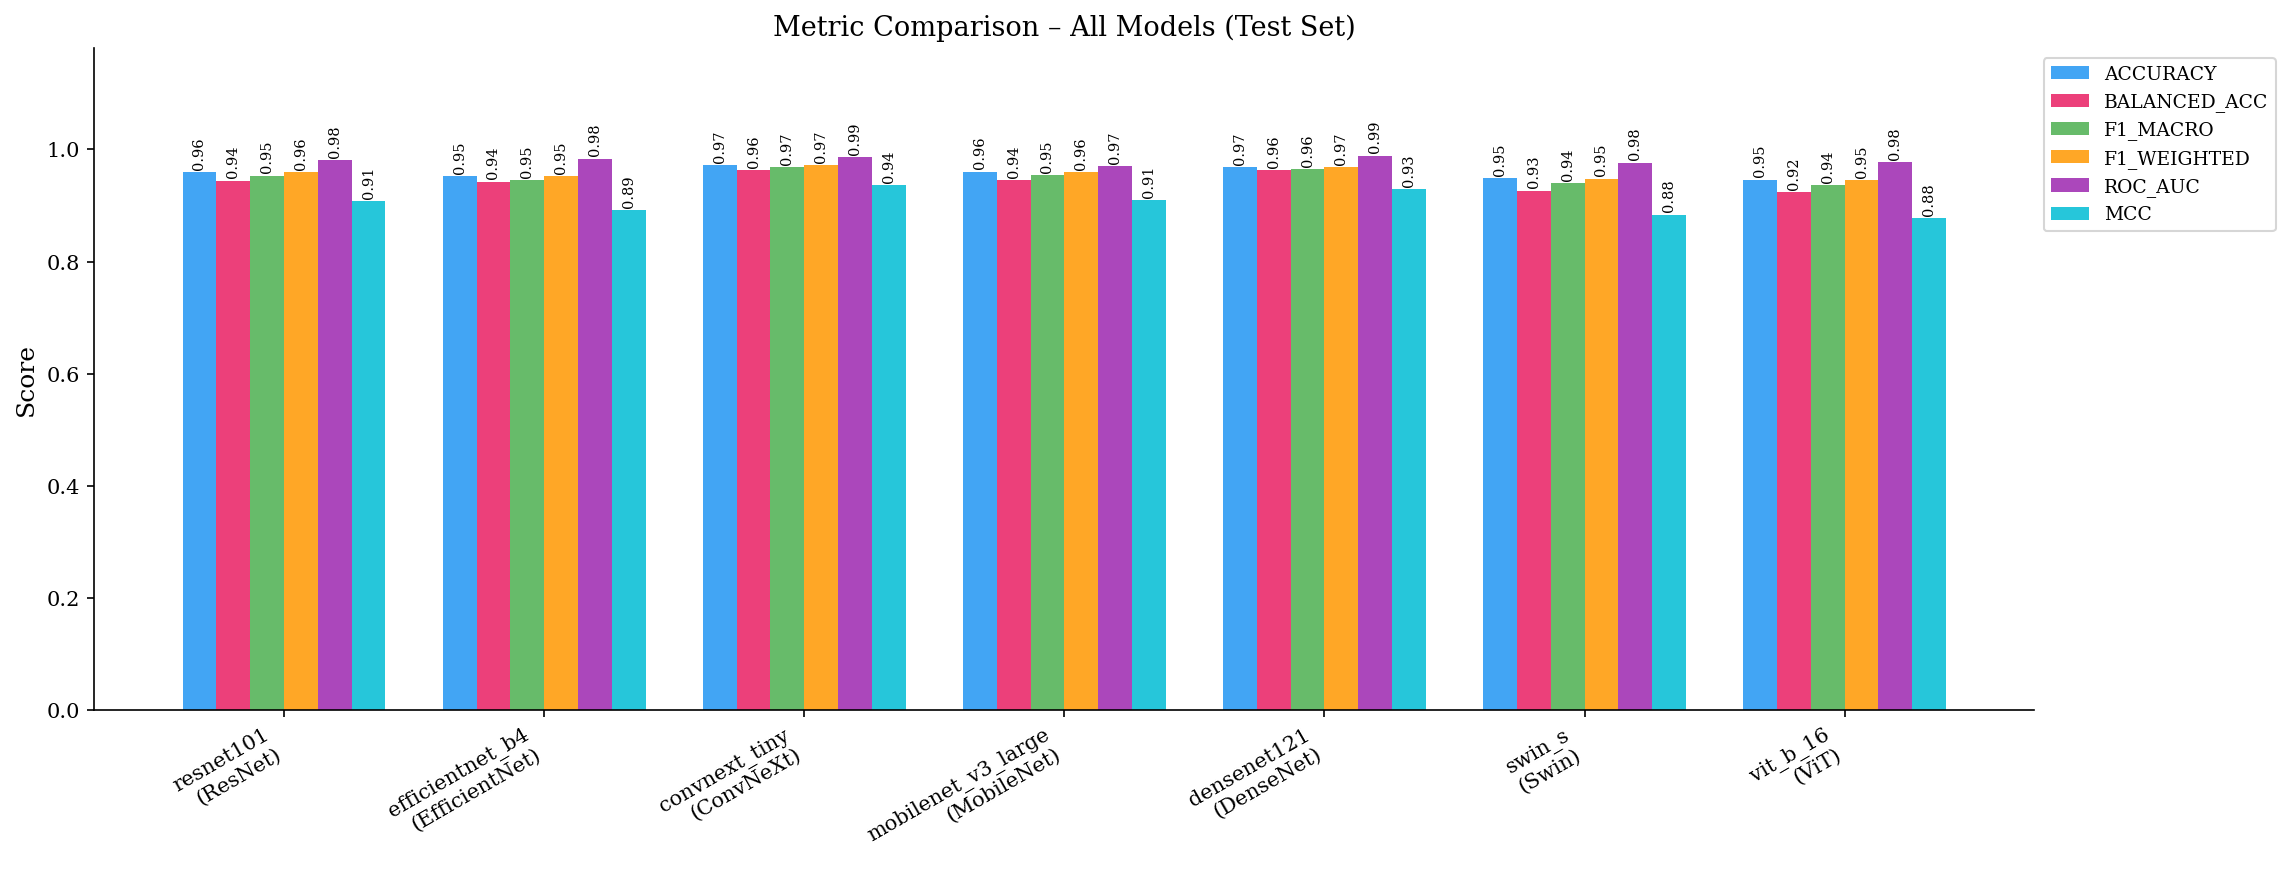

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/metric_comparison_bar.png


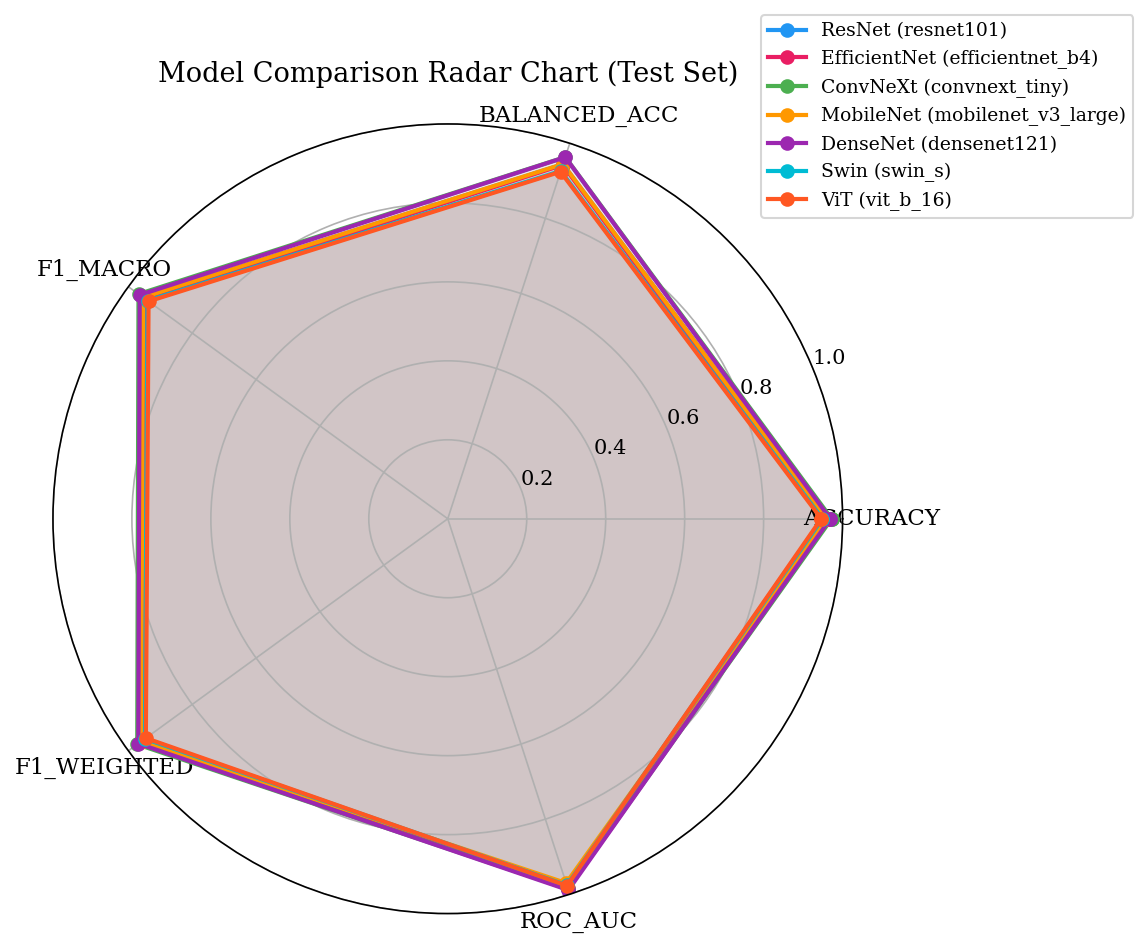

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/radar_chart.png


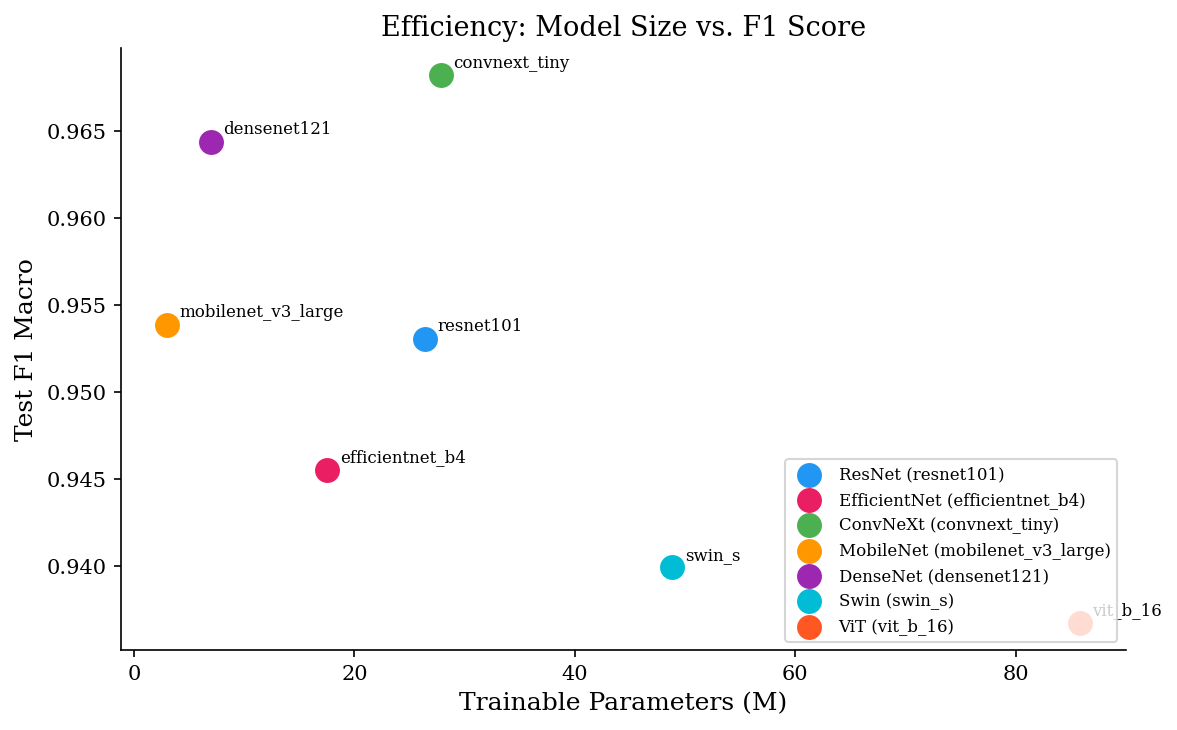

✅ Saved: /home/user/SolarVortex/BinaryDetection/Optuna/experimentA_split/benchmark_results/plots/params_vs_f1.png

📊 Benchmark Summary Table (sorted by Test F1 Macro):
      Family              Model  CBAM  Freeze Optimizer Scheduler       LR  Batch Val Acc Val F1 Val AUC Test Acc Test Bal.Acc Test F1 Macro Test F1 Weighted Test AUC Test PR-AUC    MCC Params (M) Trainable (M)
    ConvNeXt      convnext_tiny False    none     AdamW      step 1.08e-04     32  0.9751 0.9715  0.9886   0.9723       0.9632        0.9682           0.9722   0.9863      0.9891 0.9368       27.8          27.8
    DenseNet        densenet121 False    none     AdamW    cosine 1.43e-04     32  0.9730 0.9690  0.9851   0.9688       0.9628        0.9644           0.9687   0.9889      0.9928 0.9288        7.0           7.0
   MobileNet mobilenet_v3_large False    none     AdamW    cosine 2.31e-04     32  0.9602 0.9537  0.9755   0.9603       0.9447        0.9538           0.9598   0.9702      0.9730 0.9094        3.0   

In [9]:
# %%
# ===========================================================================
# MODULE 7: Final Training & Full Evaluation
# ===========================================================================

def compute_full_metrics(model, loader, class_names):
    """
    Computes research-paper quality metrics on the given loader:
    accuracy, balanced accuracy, F1 (macro + weighted), MCC,
    ROC-AUC, PR-AUC, confusion matrix, per-class report.
    """
    criterion = nn.CrossEntropyLoss()
    _, acc, f1_macro, preds, labels, probs = evaluate(model, loader, criterion)

    f1_weighted = f1_score(labels, preds, average="weighted", zero_division=0)
    bal_acc     = balanced_accuracy_score(labels, preds)
    mcc         = matthews_corrcoef(labels, preds)
    cm          = confusion_matrix(labels, preds)
    report      = classification_report(
        labels, preds, target_names=class_names, output_dict=True, zero_division=0)

    # Binary ROC / PR (positive = class index 1)
    pos_probs        = probs[:, 1]
    fpr, tpr, _      = roc_curve(labels, pos_probs)
    roc_auc          = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(labels, pos_probs)
    pr_auc           = average_precision_score(labels, pos_probs)

    return {
        "accuracy":               acc,
        "balanced_acc":           bal_acc,
        "f1_macro":               f1_macro,
        "f1_weighted":            f1_weighted,
        "mcc":                    mcc,
        "roc_auc":                roc_auc,
        "pr_auc":                 pr_auc,
        "confusion_matrix":       cm.tolist(),
        "classification_report":  report,
        "roc_curve":              (fpr.tolist(), tpr.tolist()),
        "pr_curve":               (precision.tolist(), recall.tolist()),
        "predictions":            preds.tolist(),
        "labels":                 labels.tolist(),
        "probabilities":          probs.tolist(),
    }


def final_train_and_evaluate(family_name: str, best_params: dict):
    """
    Full retraining with best Optuna params for N_EPOCHS_FINAL, then
    evaluates on val and test sets and persists the checkpoint + metrics.
    """
    print(f"\n{'='*70}")
    print(f"🏋️  Final Training: {family_name}")
    print(f"    Params: {best_params}")
    print(f"{'='*70}")

    model_key  = best_params["model_key"]
    optimizer_ = best_params["optimizer"]
    scheduler_ = best_params["scheduler"]
    lr         = best_params["lr"]
    wd         = best_params["weight_decay"]
    dropout    = best_params["dropout"]
    batch_size = best_params["batch_size"]
    use_cbam   = best_params.get("use_cbam", False)
    freeze     = best_params["freeze"]

    model      = build_model(model_key, use_cbam, freeze, dropout, CFG.NUM_CLASSES)
    loaders, _ = build_dataloaders(batch_size)
    total_p, train_p = count_params(model)
    print(f"   Parameters: total={total_p:,}  trainable={train_p:,}")

    opt   = build_optimizer(optimizer_, model, lr, wd)
    sched = build_scheduler(scheduler_, opt, CFG.N_EPOCHS_FINAL, len(loaders["train"]))

    history, best_weights, _ = run_training(
        model, loaders, CFG.N_EPOCHS_FINAL, opt, sched, scheduler_)

    # Save checkpoint
    ckpt_path = CFG.RESULTS_DIR / "checkpoints" / f"{family_name}_{model_key}_best.pth"
    torch.save({
        "model_key":   model_key,
        "use_cbam":    use_cbam,
        "freeze":      freeze,
        "dropout":     dropout,
        "state_dict":  best_weights,
        "best_params": best_params,
    }, str(ckpt_path))
    print(f"   ✅ Checkpoint saved → {ckpt_path}")

    # Evaluate on val and test sets
    model.load_state_dict(best_weights)
    test_metrics = compute_full_metrics(model, loaders["test"], CFG.CLASS_NAMES)
    val_metrics  = compute_full_metrics(model, loaders["val"],  CFG.CLASS_NAMES)

    result = {
        "family":           family_name,
        "model_key":        model_key,
        "use_cbam":         use_cbam,
        "freeze":           freeze,
        "best_params":      best_params,
        "history":          dict(history),
        "val_metrics":      val_metrics,
        "test_metrics":     test_metrics,
        "total_params":     total_p,
        "trainable_params": train_p,
    }

    # Serialize and save per-model JSON
    def _ser(obj):
        if isinstance(obj, np.ndarray):          return obj.tolist()
        if isinstance(obj, (np.integer,)):        return int(obj)
        if isinstance(obj, (np.floating,)):       return float(obj)
        if isinstance(obj, dict):                 return {k: _ser(v) for k, v in obj.items()}
        if isinstance(obj, list):                 return [_ser(i) for i in obj]
        return obj

    metrics_path = CFG.RESULTS_DIR / "metrics" / f"{family_name}_{model_key}_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(_ser(result), f, indent=2)

    torch.cuda.empty_cache()
    return result


def run_all_final_training(all_best_params: dict):
    """Retrain all families and collect results into BENCHMARK_RESULTS."""
    for family, params in all_best_params.items():
        result = final_train_and_evaluate(family, params)
        BENCHMARK_RESULTS[family] = result
    return BENCHMARK_RESULTS


# %%
# ===========================================================================
# MODULE 8: Research-Grade Visualization & Reporting
# ===========================================================================

# Apply a clean, paper-ready matplotlib style
PAPER_STYLE = {
    "figure.dpi":        150,
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    12,
    "legend.fontsize":   10,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
}
plt.rcParams.update(PAPER_STYLE)

# Distinct palette for up to 10 model families
PALETTE = [
    "#2196F3", "#E91E63", "#4CAF50", "#FF9800",
    "#9C27B0", "#00BCD4", "#FF5722", "#607D8B",
    "#795548", "#F44336",
]


def plot_training_curves(results: dict, save_dir: Path):
    """Loss and F1/accuracy curves for every family, stacked vertically."""
    families = list(results.keys())
    n   = len(families)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = [axes]

    for i, (family, res) in enumerate(results.items()):
        h  = res["history"]
        ax_loss, ax_acc = axes[i]
        ep = range(1, len(h["train_loss"]) + 1)

        ax_loss.plot(ep, h["train_loss"], label="Train Loss", color=PALETTE[0], lw=2)
        ax_loss.plot(ep, h["val_loss"],   label="Val Loss",   color=PALETTE[1], lw=2)
        ax_loss.set_title(f"{family}  ({res['model_key']}) – Loss")
        ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("CE Loss")
        ax_loss.legend()

        ax_acc.plot(ep, h["train_acc"], label="Train Acc", color=PALETTE[0], lw=2)
        ax_acc.plot(ep, h["val_acc"],   label="Val Acc",   color=PALETTE[1], lw=2)
        ax_acc.plot(ep, h["val_f1"],    label="Val F1",    color=PALETTE[2], lw=2, ls="--")
        ax_acc.set_title(f"{family}  ({res['model_key']}) – Accuracy / F1")
        ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Score")
        ax_acc.legend()

    plt.suptitle("Training Curves – All Model Families", fontweight="bold", y=1.01)
    plt.tight_layout()
    path = save_dir / "training_curves.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def plot_confusion_matrices(results: dict, save_dir: Path):
    """Grid of normalised confusion matrices for all families."""
    families = list(results.keys())
    n    = len(families)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = np.array(axes).flatten()

    for i, (family, res) in enumerate(results.items()):
        cm      = np.array(res["test_metrics"]["confusion_matrix"], dtype=float)
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        sns.heatmap(
            cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CFG.CLASS_NAMES, yticklabels=CFG.CLASS_NAMES,
            ax=axes[i], cbar=False, linewidths=0.5,
        )
        f1 = res["test_metrics"]["f1_macro"]
        axes[i].set_title(f"{family}\n({res['model_key']})\nF1={f1:.3f}")
        axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("True")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Confusion Matrices (Normalised) – Test Set", fontweight="bold")
    plt.tight_layout()
    path = save_dir / "confusion_matrices.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def plot_roc_curves(results: dict, save_dir: Path):
    """Overlaid ROC curves for all families."""
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.50)")

    for i, (family, res) in enumerate(results.items()):
        fpr, tpr = res["test_metrics"]["roc_curve"]
        roc_auc  = res["test_metrics"]["roc_auc"]
        ax.plot(fpr, tpr, color=PALETTE[i % len(PALETTE)], lw=2,
                label=f"{family} ({res['model_key']})  AUC={roc_auc:.3f}")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves – Test Set")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    plt.tight_layout()
    path = save_dir / "roc_curves.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def plot_pr_curves(results: dict, save_dir: Path):
    """Overlaid Precision-Recall curves for all families."""
    fig, ax = plt.subplots(figsize=(7, 6))

    for i, (family, res) in enumerate(results.items()):
        prec, rec = res["test_metrics"]["pr_curve"]
        pr_auc    = res["test_metrics"]["pr_auc"]
        ax.plot(rec, prec, color=PALETTE[i % len(PALETTE)], lw=2,
                label=f"{family} ({res['model_key']})  AP={pr_auc:.3f}")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves – Test Set")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    plt.tight_layout()
    path = save_dir / "pr_curves.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def plot_metric_comparison_bar(results: dict, save_dir: Path):
    """Grouped bar chart comparing all key metrics side by side."""
    metrics_keys = ["accuracy", "balanced_acc", "f1_macro", "f1_weighted", "roc_auc", "mcc"]
    labels = [f"{v['model_key']}\n({k})" for k, v in results.items()]
    x      = np.arange(len(labels))
    width  = 0.13
    n_m    = len(metrics_keys)

    fig, ax = plt.subplots(figsize=(max(12, len(labels) * 2.2), 6))

    for j, metric in enumerate(metrics_keys):
        vals   = [res["test_metrics"][metric] for res in results.values()]
        offset = (j - n_m / 2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=metric.upper(),
                        color=PALETTE[j % len(PALETTE)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=7, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.18)
    ax.set_title("Metric Comparison – All Models (Test Set)")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9)
    plt.tight_layout()
    path = save_dir / "metric_comparison_bar.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def plot_radar_chart(results: dict, save_dir: Path):
    """Spider / radar chart showing multi-metric model comparison."""
    metrics = ["accuracy", "balanced_acc", "f1_macro", "f1_weighted", "roc_auc"]
    N       = len(metrics)
    angles  = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for i, (family, res) in enumerate(results.items()):
        vals  = [res["test_metrics"][m] for m in metrics]
        vals += vals[:1]
        label = f"{family} ({res['model_key']})"
        ax.plot(angles, vals, "o-", lw=2, color=PALETTE[i % len(PALETTE)], label=label)
        ax.fill(angles, vals, alpha=0.07, color=PALETTE[i % len(PALETTE)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.upper() for m in metrics], size=11)
    ax.set_ylim(0, 1)
    ax.set_title("Model Comparison Radar Chart (Test Set)", size=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.15), fontsize=9)
    plt.tight_layout()
    path = save_dir / "radar_chart.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def plot_params_vs_f1(results: dict, save_dir: Path):
    """Efficiency scatter: trainable parameters (M) vs. test F1 macro."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (family, res) in enumerate(results.items()):
        x_val = res["trainable_params"] / 1e6
        y_val = res["test_metrics"]["f1_macro"]
        ax.scatter(x_val, y_val, s=120, color=PALETTE[i % len(PALETTE)],
                   zorder=5, label=f"{family} ({res['model_key']})")
        ax.annotate(res["model_key"], (x_val, y_val),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

    ax.set_xlabel("Trainable Parameters (M)")
    ax.set_ylabel("Test F1 Macro")
    ax.set_title("Efficiency: Model Size vs. F1 Score")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    path = save_dir / "params_vs_f1.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {path}")


def build_summary_table(results: dict, save_dir: Path) -> pd.DataFrame:
    """Assembles the master benchmark table and saves CSV + LaTeX for the paper."""
    rows = []
    for family, res in results.items():
        tm  = res["test_metrics"]
        vm  = res["val_metrics"]
        bp  = res["best_params"]
        rows.append({
            "Family":           family,
            "Model":            res["model_key"],
            "CBAM":             res["use_cbam"],
            "Freeze":           res["freeze"],
            "Optimizer":        bp.get("optimizer", "-"),
            "Scheduler":        bp.get("scheduler", "-"),
            "LR":               f"{bp.get('lr', 0):.2e}",
            "Batch":            bp.get("batch_size", "-"),
            # Validation
            "Val Acc":          f"{vm['accuracy']:.4f}",
            "Val F1":           f"{vm['f1_macro']:.4f}",
            "Val AUC":          f"{vm['roc_auc']:.4f}",
            # Test
            "Test Acc":         f"{tm['accuracy']:.4f}",
            "Test Bal.Acc":     f"{tm['balanced_acc']:.4f}",
            "Test F1 Macro":    f"{tm['f1_macro']:.4f}",
            "Test F1 Weighted": f"{tm['f1_weighted']:.4f}",
            "Test AUC":         f"{tm['roc_auc']:.4f}",
            "Test PR-AUC":      f"{tm['pr_auc']:.4f}",
            "MCC":              f"{tm['mcc']:.4f}",
            "Params (M)":       f"{res['total_params'] / 1e6:.1f}",
            "Trainable (M)":    f"{res['trainable_params'] / 1e6:.1f}",
        })

    df = pd.DataFrame(rows).sort_values("Test F1 Macro", ascending=False).reset_index(drop=True)

    csv_path   = save_dir / "metrics" / "benchmark_summary.csv"
    latex_path = save_dir / "metrics" / "benchmark_table.tex"
    df.to_csv(csv_path, index=False)
    df.to_latex(
        latex_path, index=False, escape=True,
        caption="Benchmark Results – Solar Cell EL Image Classification",
        label="tab:benchmark",
    )

    print("\n📊 Benchmark Summary Table (sorted by Test F1 Macro):")
    print(df.to_string(index=False))
    print(f"\n✅ CSV   saved → {csv_path}")
    print(f"✅ LaTeX saved → {latex_path}")
    return df


def generate_all_visualisations(results: dict):
    """Master helper: generates every figure and the summary table."""
    print("\n🎨 Generating all research-grade visualisations …")
    plot_dir = CFG.RESULTS_DIR / "plots"
    plot_training_curves(results, plot_dir)
    plot_confusion_matrices(results, plot_dir)
    plot_roc_curves(results, plot_dir)
    plot_pr_curves(results, plot_dir)
    plot_metric_comparison_bar(results, plot_dir)
    plot_radar_chart(results, plot_dir)
    plot_params_vs_f1(results, plot_dir)
    summary_df = build_summary_table(results, CFG.RESULTS_DIR)
    print("\n✅ All visualisations saved!")
    return summary_df


# %%
# ===========================================================================
# MAIN EXECUTION  —  Run this cell last
# ===========================================================================

print("=" * 70)
print("  SOLAR CELL EL IMAGE CLASSIFICATION — OPTUNA BENCHMARK")
print("=" * 70)
print(f"  Data root      : {CFG.DATA_ROOT}")
print(f"  Results dir    : {CFG.RESULTS_DIR}")
print(f"  Device         : {DEVICE}")
print(f"  Model families : {list(CFG.MODEL_FAMILIES.keys())}")
print(f"  Trials/family  : {CFG.N_TRIALS}")
print(f"  Epochs (trial) : {CFG.N_EPOCHS_TRIAL}")
print(f"  Epochs (final) : {CFG.N_EPOCHS_FINAL}")
print("=" * 70)

# STEP 1: Run Optuna HPO for every model family
all_best_params, all_best_scores = run_all_optuna()

# STEP 2: Final full-length retraining with best configs
final_results = run_all_final_training(all_best_params)

# STEP 3: Persist master results JSON
master_path = CFG.RESULTS_DIR / "metrics" / "all_results.json"

def _serial(obj):
    if isinstance(obj, np.ndarray):          return obj.tolist()
    if isinstance(obj, (np.integer,)):        return int(obj)
    if isinstance(obj, (np.floating,)):       return float(obj)
    if isinstance(obj, dict):                 return {k: _serial(v) for k, v in obj.items()}
    if isinstance(obj, list):                 return [_serial(i) for i in obj]
    return obj

with open(master_path, "w") as f:
    json.dump(_serial(final_results), f, indent=2)
print(f"\n✅ Master results JSON saved → {master_path}")

# STEP 4: Generate all plots + summary table
summary_df = generate_all_visualisations(final_results)

print("\n🎉  BENCHMARK COMPLETE!")
print(f"    Best model : {summary_df.iloc[0]['Model']}  "
      f"(F1 = {summary_df.iloc[0]['Test F1 Macro']})")
